# Knowledge Graph Construction with Claude

You have a pile of unstructured documents and need to answer questions that span them — "who works with people who worked on project X", "which vendors are connected to this incident". No single document contains the answer. RAG retrieval won't chain the facts for you. You need a knowledge graph: **entities** as nodes, **typed relations** as edges, so that multi-hop reasoning becomes graph traversal.

Building one used to mean training a named-entity recognizer on your domain, training a relation classifier, writing entity-resolution heuristics, and maintaining all three as your data shifted. With Claude, each of those stages becomes a prompt.

## What you'll learn

By the end of this guide you will be able to:

- Use **forced tool use** to extract typed entities and subject–predicate–object triples from arbitrary text with no training data
- Apply **Claude-driven entity resolution** to collapse surface-form variants into canonical nodes, replacing brittle string-similarity heuristics
- Assemble and query an in-memory graph, and run **multi-hop questions** by serializing subgraphs back to Claude
- Measure extraction quality with **precision/recall against a gold set** and reason about the cost/quality tradeoff between Haiku and Sonnet

Everything runs in memory with no database. The techniques transfer directly to Neo4j, Neptune, or a Postgres adjacency table when you need to scale.

## Prerequisites
- Python 3.11+
- Anthropic API key ([get one here](https://console.anthropic.com))
- Basic familiarity with graphs (nodes, edges, traversal)

## Setup

In [1]:
%%capture
%pip install anthropic requests networkx matplotlib python-dotenv

In [2]:
import json
from collections import defaultdict
from pathlib import Path
from urllib.parse import quote

import anthropic
import matplotlib.pyplot as plt
import networkx as nx
import requests
from dotenv import load_dotenv

load_dotenv()
client = anthropic.Anthropic()

EXTRACTION_MODEL = "claude-haiku-4-5"
SYNTHESIS_MODEL = "claude-sonnet-4-6"


def tool_output(response: anthropic.types.Message, name: str) -> dict:
    block = next((b for b in response.content if b.type == "tool_use" and b.name == name), None)
    if block is None:
        raise ValueError(
            f"No {name!r} tool_use block in response (stop_reason={response.stop_reason})"
        )
    return block.input

We use two models. Haiku handles the high-volume, schema-constrained extraction work where speed and cost matter more than nuance. Sonnet handles entity resolution and summarization, where the model needs to weigh conflicting evidence across documents.

## Building a corpus

We need a handful of documents that talk about overlapping entities, so that entity resolution has real work to do. The Apollo program is a good test bed: six short Wikipedia summaries that all mention NASA, the Moon, several astronauts, and a launch vehicle — but each article names them slightly differently.

We fetch summaries from the Wikipedia REST API rather than full articles to keep token costs low. For a production pipeline you would chunk full documents; the extraction logic is identical.

In [3]:
ARTICLE_TITLES = [
    "Apollo program",
    "Apollo 11",
    "Neil Armstrong",
    "Saturn V",
    "Buzz Aldrin",
    "Kennedy Space Center",
]

WIKI_API = "https://en.wikipedia.org/api/rest_v1/page/summary/"
HEADERS = {"User-Agent": "claude-cookbooks/1.0 (https://github.com/anthropics/claude-cookbooks)"}


def fetch_summary(title: str) -> str:
    slug = quote(title.replace(" ", "_"), safe="")
    r = requests.get(WIKI_API + slug, headers=HEADERS, timeout=10)
    r.raise_for_status()
    return r.json()["extract"]


documents = []
for i, title in enumerate(ARTICLE_TITLES):
    try:
        documents.append({"id": i, "title": title, "text": fetch_summary(title)})
    except requests.RequestException as e:
        print(f"Skipping {title}: {e}")

print(f"Loaded {len(documents)} documents\n")
if documents:
    print(f"Sample — {documents[0]['title']}:\n{documents[0]['text'][:300]}...")

Loaded 6 documents

Sample — Apollo program:
The Apollo program, also known as Project Apollo, was the United States human spaceflight program led by NASA, which landed the first humans on the Moon in 1969. Apollo was conceived during Project Mercury and executed after Project Gemini. It was conceived in 1960 as a three-person spacecraft durin...


## Entity and relation extraction

Classical NER tags spans of text with labels (PERSON, ORG, LOC). Classical relation extraction then classifies pairs of spans into relation types. Both traditionally require labeled training data per domain.

We collapse both stages into a single Claude call per document. The key is **forced tool use**: by setting `tool_choice` to a specific tool name, we guarantee the response is a well-formed JSON object matching our schema. No regex parsing, no malformed output recovery.

In [4]:
ENTITY_TYPES = ["PERSON", "ORGANIZATION", "LOCATION", "EVENT", "ARTIFACT"]

extract_tool = {
    "name": "extract_graph",
    "description": "Record the entities and relations found in a document.",
    "input_schema": {
        "type": "object",
        "properties": {
            "entities": {
                "type": "array",
                "items": {
                    "type": "object",
                    "properties": {
                        "name": {
                            "type": "string",
                            "description": "The entity's name exactly as it appears or is most commonly referred to in this document.",
                        },
                        "type": {"type": "string", "enum": ENTITY_TYPES},
                        "description": {
                            "type": "string",
                            "description": "One sentence grounded in this document. Used later to disambiguate entities with similar names.",
                        },
                    },
                    "required": ["name", "type", "description"],
                },
            },
            "relations": {
                "type": "array",
                "items": {
                    "type": "object",
                    "properties": {
                        "source": {
                            "type": "string",
                            "description": "Name of the source entity (must appear in entities above).",
                        },
                        "predicate": {
                            "type": "string",
                            "description": "Short verb phrase: 'commanded', 'launched from', 'part of'.",
                        },
                        "target": {
                            "type": "string",
                            "description": "Name of the target entity (must appear in entities above).",
                        },
                    },
                    "required": ["source", "predicate", "target"],
                },
            },
        },
        "required": ["entities", "relations"],
    },
}

EXTRACTION_PROMPT = """Extract a knowledge graph from the document below.

<document>
{text}
</document>

Extract only entities that are central to what this document is about — skip incidental mentions. Every relation must connect two entities you extracted."""


def extract(text: str) -> dict:
    response = client.messages.create(
        model=EXTRACTION_MODEL,
        max_tokens=2048,
        tools=[extract_tool],
        tool_choice={"type": "tool", "name": "extract_graph"},
        messages=[{"role": "user", "content": EXTRACTION_PROMPT.format(text=text)}],
    )
    return tool_output(response, "extract_graph")

In [5]:
raw_entities = []
raw_relations = []

for doc in documents:
    try:
        result = extract(doc["text"])
    except (ValueError, anthropic.APIError) as e:
        print(f"Skipping {doc['title']}: {e}")
        continue
    for ent in result["entities"]:
        ent["source_doc"] = doc["title"]
        raw_entities.append(ent)
    for rel in result["relations"]:
        rel["source_doc"] = doc["title"]
        raw_relations.append(rel)
    print(
        f"{doc['title']:<25} {len(result['entities']):>3} entities  {len(result['relations']):>3} relations"
    )

print(f"\nTotal: {len(raw_entities)} raw entities, {len(raw_relations)} raw relations")

Apollo program              6 entities    5 relations


Apollo 11                   7 entities    6 relations


Neil Armstrong              3 entities    3 relations


Saturn V                    5 entities    5 relations


Buzz Aldrin                 7 entities    7 relations


Kennedy Space Center        8 entities    8 relations

Total: 36 raw entities, 34 raw relations


Let's look at what was extracted. Notice how the same real-world entity appears under different surface forms across documents — this is the entity resolution problem we solve next.

In [6]:
by_type = defaultdict(list)
for e in raw_entities:
    by_type[e["type"]].append(e["name"])

for etype, names in sorted(by_type.items()):
    print(f"{etype} ({len(names)}):")
    for name in sorted(set(names)):
        print(f"  {name}")
    print()

ARTIFACT (4):
  Gemini 12
  Launch Complex 39
  Saturn V
  Skylab

EVENT (11):
  Apollo 11
  Apollo program
  Project Gemini
  Project Mercury
  Skylab program
  Space Shuttle program

LOCATION (6):
  Merritt Island, Florida
  Moon
  the Moon

ORGANIZATION (6):
  Cape Canaveral Space Force Station
  John F. Kennedy Space Center
  NASA

PERSON (9):
  Buzz Aldrin
  Edwin Aldrin
  Jim Lovell
  John F. Kennedy
  Michael Collins
  Neil Alden Armstrong
  Neil Armstrong



## Entity resolution

The raw extraction gives us overlapping mentions: "NASA" and "National Aeronautics and Space Administration", "Neil Armstrong" and "Armstrong", possibly "the Moon" and "Moon". If we build a graph directly from this, we get a fractured mess where the same concept is split across disconnected nodes.

Traditional approaches use string similarity (edit distance, Jaccard on tokens) plus blocking rules. That works for typos but fails on "Edwin Aldrin" vs "Buzz Aldrin" — two names with zero character overlap that refer to the same person.

We instead ask Claude to cluster entities of each type, using the one-line descriptions from extraction as disambiguation context. The descriptions matter: "Armstrong — first person to walk on the Moon" and "Armstrong — jazz trumpeter" have the same name but should not merge.

In [7]:
resolve_tool = {
    "name": "resolve_entities",
    "description": "Group entity mentions that refer to the same real-world thing.",
    "input_schema": {
        "type": "object",
        "properties": {
            "clusters": {
                "type": "array",
                "items": {
                    "type": "object",
                    "properties": {
                        "canonical": {
                            "type": "string",
                            "description": "The most complete, unambiguous name for this entity.",
                        },
                        "aliases": {
                            "type": "array",
                            "items": {"type": "string"},
                            "description": "Every input name that refers to this entity, including the canonical one.",
                        },
                    },
                    "required": ["canonical", "aliases"],
                },
            }
        },
        "required": ["clusters"],
    },
}

RESOLVE_PROMPT = """Below are {entity_type} entities extracted from several documents. Some are different surface forms of the same real-world entity.

<entities>
{entity_list}
</entities>

Cluster them. Each input name must appear in exactly one cluster's aliases list. Entities that are genuinely distinct get their own single-element cluster. Use the descriptions to avoid merging entities that merely share a name."""


def resolve(entity_type: str, entities: list[dict]) -> list[dict]:
    unique = {}
    for e in entities:
        unique.setdefault(e["name"], e["description"])
    entity_list = "\n".join(f"- {name}: {desc}" for name, desc in unique.items())

    response = client.messages.create(
        model=SYNTHESIS_MODEL,
        max_tokens=2048,
        tools=[resolve_tool],
        tool_choice={"type": "tool", "name": "resolve_entities"},
        messages=[
            {
                "role": "user",
                "content": RESOLVE_PROMPT.format(entity_type=entity_type, entity_list=entity_list),
            }
        ],
    )
    return tool_output(response, "resolve_entities")["clusters"]

In [8]:
alias_to_canonical = {}
canonical_info = {}

for etype in ENTITY_TYPES:
    entities_of_type = [e for e in raw_entities if e["type"] == etype]
    if not entities_of_type:
        continue
    try:
        clusters = resolve(etype, entities_of_type)
    except (ValueError, anthropic.APIError) as e:
        print(f"Resolve failed for {etype}: {e}; treating each name as its own cluster")
        clusters = [{"canonical": n, "aliases": [n]} for n in {x["name"] for x in entities_of_type}]
    for cluster in clusters:
        canonical = cluster["canonical"]
        canonical_info[canonical] = {"type": etype, "aliases": cluster["aliases"]}
        for alias in cluster["aliases"]:
            alias_to_canonical[alias] = canonical

before = len({e["name"] for e in raw_entities})
after = len(canonical_info)
print(f"Entity resolution: {before} unique names → {after} canonical entities\n")

for canonical, info in sorted(canonical_info.items()):
    aliases = [a for a in info["aliases"] if a != canonical]
    alias_str = f"  (also: {', '.join(aliases)})" if aliases else ""
    print(f"{info['type']:<14} {canonical}{alias_str}")

Entity resolution: 23 unique names → 20 canonical entities

EVENT          Apollo 11
EVENT          Apollo program
PERSON         Buzz Aldrin  (also: Edwin Aldrin)
ORGANIZATION   Cape Canaveral Space Force Station
ARTIFACT       Gemini 12
PERSON         Jim Lovell
PERSON         John F. Kennedy
ORGANIZATION   John F. Kennedy Space Center
ARTIFACT       Launch Complex 39
LOCATION       Merritt Island, Florida
PERSON         Michael Collins
ORGANIZATION   NASA
PERSON         Neil Alden Armstrong  (also: Neil Armstrong)
EVENT          Project Gemini
EVENT          Project Mercury
ARTIFACT       Saturn V
ARTIFACT       Skylab
EVENT          Skylab program
EVENT          Space Shuttle program
LOCATION       the Moon  (also: Moon)


One caveat: any raw name Claude leaves out of every cluster silently disappears from the graph, because `alias_to_canonical` has no entry for it. That's acceptable here — the resolver is reliable on a small, clean corpus. A production resolver should fall back to a single-element cluster for unmatched names so nothing is lost, then flag those singletons for review.

## Assembling the graph

With a clean alias map, we rewrite every relation endpoint to its canonical form and load the result into NetworkX. We use a `MultiDiGraph` because two entities can be connected by several distinct predicates ("launched from" and "operated by"), and direction matters ("Armstrong commanded Apollo 11" is not the same edge as "Apollo 11 commanded Armstrong").

Each node carries its type, the set of documents that mention it, and a mention count. Each edge carries its predicate and source document.

In [9]:
G = nx.MultiDiGraph()

for e in raw_entities:
    canonical = alias_to_canonical.get(e["name"])
    if canonical is None:
        continue
    if canonical not in G:
        G.add_node(
            canonical,
            type=canonical_info[canonical]["type"],
            description=e["description"],
            source_docs=set(),
            mentions=0,
        )
    G.nodes[canonical]["source_docs"].add(e["source_doc"])
    G.nodes[canonical]["mentions"] += 1

for r in raw_relations:
    src = alias_to_canonical.get(r["source"])
    tgt = alias_to_canonical.get(r["target"])
    if src and tgt and src != tgt:
        G.add_edge(src, tgt, predicate=r["predicate"], source_doc=r["source_doc"])

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Connected components: {nx.number_weakly_connected_components(G)}")
print("\nMost connected entities:")
for node, deg in sorted(G.degree(), key=lambda x: -x[1])[:5]:
    print(f"  {node:<35} degree {deg:>2}  ({G.nodes[node]['type']})")

Graph: 20 nodes, 34 edges
Connected components: 2

Most connected entities:
  Apollo 11                           degree 11  (EVENT)
  Apollo program                      degree 10  (EVENT)
  the Moon                            degree  7  (LOCATION)
  NASA                                degree  5  (ORGANIZATION)
  Neil Alden Armstrong                degree  5  (PERSON)


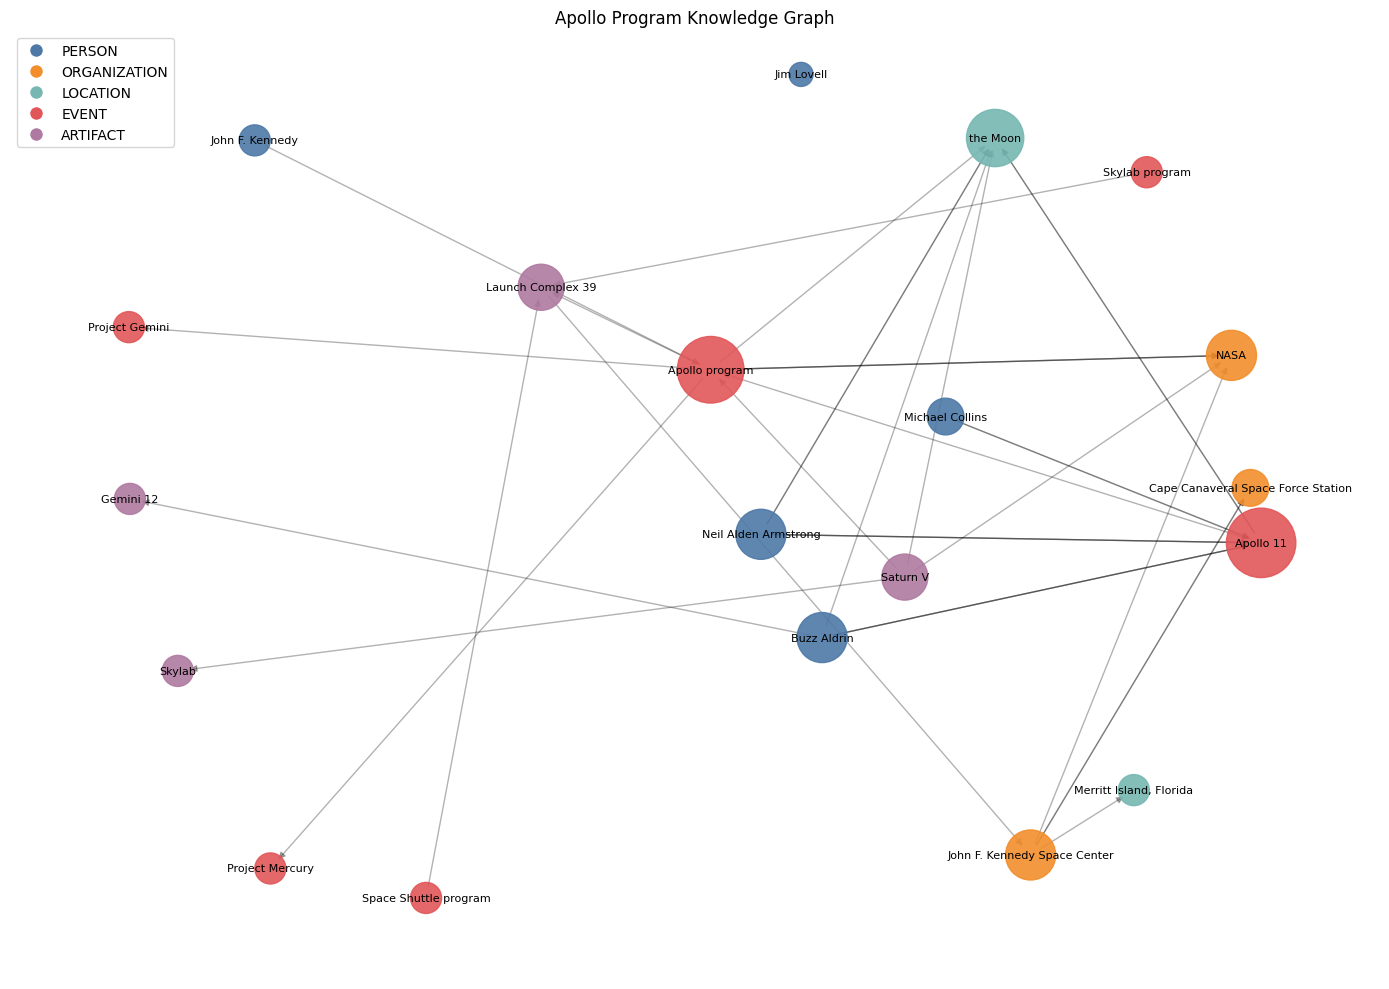

In [10]:
COLOR = {
    "PERSON": "#4e79a7",
    "ORGANIZATION": "#f28e2c",
    "LOCATION": "#76b7b2",
    "EVENT": "#e15759",
    "ARTIFACT": "#af7aa1",
}

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, k=1.5, seed=42)
node_colors = [COLOR[G.nodes[n]["type"]] for n in G.nodes]
node_sizes = [300 + 200 * G.degree(n) for n in G.nodes]

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=8)
nx.draw_networkx_edges(G, pos, alpha=0.3, arrows=True, arrowsize=10)

handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=10, label=t)
    for t, c in COLOR.items()
    if any(G.nodes[n]["type"] == t for n in G.nodes)
]
plt.legend(handles=handles, loc="upper left")
plt.title("Apollo Program Knowledge Graph")
plt.axis("off")
plt.tight_layout()
plt.show()

## Entity summarization

Each node currently carries only the one-line description from whichever document mentioned it first. For the hub nodes — the ones that show up in many documents — we can do much better: pool every mention, add the graph neighborhood as context, and have Claude synthesize a proper profile.

This is the step that turns a graph of labels into a graph of knowledge. The summaries become the node content you surface in search results or feed to downstream QA.

In [11]:
summarize_tool = {
    "name": "summarize_entity",
    "description": "Produce a consolidated profile for a knowledge-graph entity.",
    "input_schema": {
        "type": "object",
        "properties": {
            "summary": {
                "type": "string",
                "description": "2-3 paragraph factual summary synthesized from the source excerpts. Resolve any contradictions by preferring the most specific claim.",
            },
            "key_facts": {
                "type": "array",
                "items": {"type": "string"},
                "description": "3-5 atomic facts, each traceable to the sources.",
            },
            "time_range": {
                "type": "object",
                "properties": {
                    "start": {"type": "string", "description": "YYYY or YYYY-MM, or 'unknown'"},
                    "end": {"type": "string", "description": "YYYY or YYYY-MM, or 'ongoing'"},
                },
                "required": ["start", "end"],
            },
        },
        "required": ["summary", "key_facts", "time_range"],
    },
}

SUMMARIZE_PROMPT = """Generate a knowledge-graph profile for this entity.

Entity: {name} ({etype})

Source excerpts mentioning this entity:
{excerpts}

Known relations in the graph:
{relations}

Synthesize across all sources. Do not invent facts not supported by the excerpts."""


def summarize_entity(name: str) -> dict:
    docs_with_entity = G.nodes[name]["source_docs"]
    excerpts = "\n\n".join(
        f"[{d['title']}]\n{d['text']}" for d in documents if d["title"] in docs_with_entity
    )
    relations = (
        "\n".join(
            f"- {name} --{d['predicate']}--> {tgt}" for _, tgt, d in G.out_edges(name, data=True)
        )
        + "\n"
        + "\n".join(
            f"- {src} --{d['predicate']}--> {name}" for src, _, d in G.in_edges(name, data=True)
        )
    )

    response = client.messages.create(
        model=SYNTHESIS_MODEL,
        max_tokens=1500,
        tools=[summarize_tool],
        tool_choice={"type": "tool", "name": "summarize_entity"},
        messages=[
            {
                "role": "user",
                "content": SUMMARIZE_PROMPT.format(
                    name=name, etype=G.nodes[name]["type"], excerpts=excerpts, relations=relations
                ),
            }
        ],
    )
    return tool_output(response, "summarize_entity")

In [12]:
hub_nodes = [n for n, _ in sorted(G.degree(), key=lambda x: -x[1])[:3]]

for node in hub_nodes:
    profile = summarize_entity(node)
    G.nodes[node]["profile"] = profile
    print(f"═══ {node} ═══")
    print(profile["summary"])
    print(f"\nTime range: {profile['time_range']['start']} – {profile['time_range']['end']}")
    print("Key facts:")
    for fact in profile["key_facts"]:
        print(f"  • {fact}")
    print()

═══ Apollo 11 ═══
Apollo 11 was the American spaceflight mission that achieved the first crewed lunar landing in history, making it one of the most significant events in space exploration. It was the fifth crewed mission of NASA's Apollo program, launching in 1969. The mission's crew consisted of Commander Neil Armstrong, Command Module Pilot Michael Collins, and Lunar Module Pilot Edwin "Buzz" Aldrin — all of whom were on their second and final spaceflight.

During the mission, Neil Armstrong became the first person to walk on the Moon, followed shortly by Buzz Aldrin, making him the second. Michael Collins remained in lunar orbit aboard the Command Module while Armstrong and Aldrin descended to the lunar surface in the Lunar Module Eagle. All three crew members were accomplished aviators and engineers with distinguished careers beyond Apollo 11.

Of the three crew members, Buzz Aldrin is the last surviving member following the deaths of Neil Armstrong in 2012 and Michael Collins in 2

═══ Apollo program ═══
The Apollo program, also known as Project Apollo, was the United States human spaceflight program led and managed by NASA. Originally conceived in 1960 during the presidency of Dwight D. Eisenhower as a three-person spacecraft program, it was developed out of Project Mercury and executed following Project Gemini. The program's central mission was galvanized by President John F. Kennedy's 1961 address to the U.S. Congress, in which he set the national goal of "landing a man on the Moon and returning him safely to the Earth" before the end of the 1960s.

The Apollo program achieved its historic objective on July 20, 1969, when Apollo 11 — crewed by Neil Armstrong, Michael Collins, and Buzz Aldrin — became the fifth crewed Apollo mission and the first to land humans on the Moon. Launch operations for the program were carried out from Launch Complex 39 at Kennedy Space Center on Merritt Island, Florida. The program's primary launch vehicle was the Saturn V, a three-s

═══ the Moon ═══
The Moon is Earth's natural satellite and the only extraterrestrial body on which humans have set foot. It became the central destination of the United States' Apollo program, which was conceived in 1960 and formally dedicated to the goal of "landing a man on the Moon and returning him safely to the Earth" by President John F. Kennedy in an address to Congress on May 25, 1961. The Apollo program, managed by NASA, successfully achieved this goal in 1969.

The first crewed lunar landing was accomplished by Apollo 11, whose crew consisted of Commander Neil Armstrong, Command Module Pilot Michael Collins, and Lunar Module Pilot Buzz Aldrin. Neil Armstrong became the first person to walk on the Moon, followed shortly by Buzz Aldrin as the second. Apollo 11 was the fifth crewed mission of the Apollo program, and it marked a landmark moment in human spaceflight history.

To reach the Moon, NASA developed the Saturn V, a super heavy-lift launch vehicle that was human-rated, th

## Querying the graph

The payoff of building a knowledge graph is multi-hop reasoning: answering questions that require chaining facts that never co-occur in a single document. "Which locations are connected to people who flew on Apollo 11?" needs the extractor to have found person→mission edges in one document and person→location edges in another, then the resolver to have unified the person nodes so those edges actually meet.

We serialize a relevant subgraph as triples and let Claude reason over it. For comparison, we first ask the same question with no graph context.

In [13]:
def serialize_subgraph(center: str, hops: int = 2) -> str:
    nodes = {center}
    frontier = {center}
    for _ in range(hops):
        nxt = set()
        for n in frontier:
            nxt |= set(G.successors(n)) | set(G.predecessors(n))
        frontier = nxt - nodes
        nodes |= frontier
    sub = G.subgraph(nodes)
    lines = [f"({s}) --[{d['predicate']}]--> ({t})" for s, t, d in sub.edges(data=True)]
    return "\n".join(sorted(set(lines)))


def ask(question: str, graph_context: str | None = None) -> str:
    if graph_context is not None:
        prompt = f"""Answer using only the knowledge graph below. Cite the specific edges that support your answer.

<graph>
{graph_context}
</graph>

Question: {question}"""
    else:
        prompt = question
    response = client.messages.create(
        model=SYNTHESIS_MODEL,
        max_tokens=500,
        messages=[{"role": "user", "content": prompt}],
    )
    return response.content[0].text

In [14]:
apollo_11 = next((n for n in G.nodes if "Apollo 11" in n), hub_nodes[0])
print(f"Querying 2-hop neighborhood of: {apollo_11}\n")
subgraph = serialize_subgraph(apollo_11, hops=2)

question = "Which locations are connected to people who were part of Apollo 11, and how?"

print("WITHOUT graph context:")
print(ask(question))
print("\n" + "─" * 60 + "\n")
print("WITH graph context:")
print(ask(question, subgraph))

Querying 2-hop neighborhood of: Apollo 11

WITHOUT graph context:


# Apollo 11 Crew Connections to Locations

## The Three Astronauts

### Neil Armstrong
- **Wapakoneta, Ohio** – birthplace and hometown; the **Armstrong Air & Space Museum** is located there
- **Purdue University, Indiana** – where he studied aeronautical engineering
- **University of Southern California** – where he earned his master's degree
- **Edwards Air Force Base, California** – where he worked as a test pilot

### Buzz Aldrin
- **Montclair, New Jersey** – birthplace
- **West Point, New York** – attended the U.S. Military Academy
- **MIT, Cambridge, Massachusetts** – earned his doctorate in astronautics
- **Langley, Virginia** – early NASA training

### Michael Collins
- **Rome, Italy** – birthplace (son of a U.S. Army officer)
- **Washington, D.C.** – grew up there; later directed the **National Air and Space Museum**
- **West Point** – also a graduate

## Key Mission Locations
- **Kennedy Space Center, Florida** – launch site (July 16, 1969)
- **Houston, Texas (Johnson Space C

## Locations Connected to Apollo 11 Crew Members

Based on the knowledge graph, the only location connected to people who were part of Apollo 11 is **the Moon**, with the following connections:

### Neil Alden Armstrong
- **(Neil Alden Armstrong) --[walked on]--> (the Moon)**

### Buzz Aldrin
- **(Buzz Aldrin) --[walked on]--> (the Moon)**

---

## Summary

Both **Neil Armstrong** and **Buzz Aldrin** — confirmed crew members of Apollo 11 via:
- **(Neil Alden Armstrong) --[commanded]--> (Apollo 11)**
- **(Buzz Aldrin) --[part of crew]--> (Apollo 11)**

— are directly connected to **the Moon** through the "walked on" relationship.

> **Note:** While **Michael Collins** is also confirmed as part of the Apollo 11 crew via **(Michael Collins) --[part of crew]--> (Apollo 11)**, the knowledge graph contains **no direct location edges** for him, reflecting the historical fact that he did not walk on the Moon.


The ungrounded answer draws on Claude's pretraining and may be correct — Apollo 11 is famous. But the grounded answer is **traceable**: every claim cites an edge we extracted from a specific document. On a private corpus where Claude has no prior knowledge, only the grounded answer works at all.

## Evaluation

Knowledge graph quality is measured with precision and recall against a gold set. We ship a small hand-labeled set in `data/sample_triples.json` covering two of the articles, plus `data/alias_map.json` which normalizes surface-form variants to the gold names so that "the Moon" and "Moon" count as the same hit.

The check below scores two things side by side: raw extractor output, and the same entities after passing through `alias_to_canonical` from the resolution step. When the resolver picks a canonical form the alias map knows about (or that matches gold verbatim), resolved recall climbs. When it picks a verbose form the alias map doesn't cover — say "Neil Alden Armstrong" — resolved recall can *drop*, because a name that matched gold before resolution no longer does after. That's not a resolver bug; it's a scoring artifact. The fix is to extend `alias_map.json` whenever you see a canonical form the scorer doesn't recognize.

This cell scores entities only. The standalone script also scores relations, matching on (source, target) pairs with predicate wording ignored — so its relation recall is an upper bound. Run it from the repo root:

```bash
uv run python capabilities/knowledge_graph/evaluation/eval_extraction.py
```

In [15]:
data_dir = Path("data")
if not data_dir.exists():
    data_dir = Path("capabilities/knowledge_graph/data")

with open(data_dir / "sample_triples.json", encoding="utf-8") as f:
    gold = json.load(f)
with open(data_dir / "alias_map.json", encoding="utf-8") as f:
    ALIASES = json.load(f)


def norm(name: str) -> str:
    lower = name.lower().strip()
    return ALIASES.get(lower, lower)


def prf(predicted: set, gold: set) -> tuple[float, float, float]:
    tp = len(predicted & gold)
    p = tp / len(predicted) if predicted else 0.0
    r = tp / len(gold) if gold else 0.0
    f1 = 2 * p * r / (p + r) if (p + r) else 0.0
    return p, r, f1


print("Raw extraction vs resolved-graph recall against gold:\n")
for doc_title, labels in gold.items():
    gold_names = {norm(e["name"]) for e in labels["entities"]}

    raw = {norm(e["name"]) for e in raw_entities if e["source_doc"] == doc_title}
    rp, rr, rf = prf(raw, gold_names)

    resolved = {
        norm(alias_to_canonical.get(e["name"], e["name"]))
        for e in raw_entities
        if e["source_doc"] == doc_title
    }
    _, resolved_r, _ = prf(resolved, gold_names)

    print(f"{doc_title:<20}  raw F1={rf:.2f} (P={rp:.2f} R={rr:.2f})  resolved R={resolved_r:.2f}")
    missed = gold_names - resolved
    if missed:
        print(f"  still missed after resolution: {', '.join(sorted(missed))}")

Raw extraction vs resolved-graph recall against gold:

Apollo 11             raw F1=0.78 (P=1.00 R=0.64)  resolved R=0.64
  still missed after resolution: columbia, kennedy space center, lunar module eagle, saturn v
Neil Armstrong        raw F1=0.55 (P=1.00 R=0.38)  resolved R=0.38
  still missed after resolution: gemini 8, korean war, nasa, purdue university, united states navy


## Scaling up

This notebook processed six documents in memory. Production knowledge graphs are built from thousands. A few notes on scaling:

**Extraction cost.** Haiku is cheap enough to run on large corpora, but [prompt caching](https://docs.claude.com/en/docs/build-with-claude/prompt-caching) cuts costs further when your extraction schema and instructions stay fixed — cache the tool definition and prompt preamble, pay full price only for the document text. The [Message Batches API](https://docs.claude.com/en/docs/build-with-claude/batch-processing) gives 50% off for jobs that can wait up to 24 hours.

**Entity resolution at scale.** Feeding ten thousand PERSON entities to Claude in one prompt doesn't work. Block first: group candidates by cheap signals (same last name, overlapping tokens, embedding similarity) so Claude only arbitrates within small blocks. The resolution prompt above works unchanged on blocks of 50–100.

**Incremental updates.** When a new document arrives, extract its entities, resolve them against the existing canonical set (not against each other), and add only the new edges. Re-summarize an entity only when its source-document set changes materially.

**Storage.** NetworkX is fine to a few hundred thousand edges. Beyond that, the schema maps directly onto a property graph (Neo4j, Neptune) or three Postgres tables: `entities(id, name, type, summary)`, `relations(source_id, target_id, predicate)`, `aliases(entity_id, alias)`. The extraction and resolution code doesn't change — only the persistence layer does.

## Summary

You've built a complete knowledge graph pipeline with nothing but prompts:

- **Extraction** — a single forced-tool-use call per document replaced what used to be a trained NER model plus a trained relation classifier. The schema in the tool definition is the only "training" required.
- **Resolution** — Claude clustered surface forms using the extraction descriptions as context, catching cases like "Edwin Aldrin" → "Buzz Aldrin" that string similarity misses entirely.
- **Summarization** — hub nodes got rich profiles synthesized across every document that mentioned them, with structured time ranges and traceable key facts.
- **Querying** — serialized subgraphs let Claude answer multi-hop questions with edge-level citations, grounding answers in the graph you built rather than pretraining.

The evaluation harness in `evaluation/` gives you a feedback loop: change the extraction prompt, rerun the scorer, watch the F1 move. That loop is what turns a demo into a production system.

## Related cookbooks

- [Extracting structured JSON](../../tool_use/extracting_structured_json.ipynb) — the forced tool-use pattern applied to simpler extraction tasks
- [Retrieval augmented generation](../retrieval_augmented_generation/guide.ipynb) — the complementary approach when you need document retrieval rather than fact traversal
- [Contextual embeddings](../contextual-embeddings/guide.ipynb) — enriching chunks before embedding, the same "add context before indexing" idea applied to vector search